## Uncertainty Principle Simulation Coding Project
In this project, I will be creating a runable simulation for the Heisenburg UNcertainty Princple. This principle states that both positon and momentum cannot be measured with extreme position at the same time. This inherently states that the more precision the postion is taken with, the less precise the momentunm measurement will be. This has nothing to do with our current technological capabilities, it is a property of a wave-like system. This relationship is represented by the relationship, $$\Delta x \Delta p \ge \frac{\hbar}{2}$$

This coding project goes hand and hand with the other project that I am currently working on in Quantum and Advanced Physics Project Lab. I have created a simulation to go along with the physical research that I had done so that I could compare the answers that I get from both. 

The physical project investigates the spatial-momentum uncertainty relation by utilizing focused optical beams as a macroscopic model for quantum wave packets. By employing three distinct light sources: a 405nm violet laser, a 650nm red laser, and a 625nm LED, the study seeks to verify if the Equation 1 limit holds across varying levels of spatial coherence. The experimental objective is to measure the minimum beam waist (position uncertainty) and the resulting farfield divergence (momentum uncertainty) to map the physical boundaries of the Heisenberg inequality and determine how source coherence influences the proximity to the quantum floor. See Uncertaintysetup.png for the physical setup.

## Theory 
The uncertainty principle establishes a fundamental "floor" for measurement precision. In optics, a lens that creates a narrower convergence (decreasing ∆x) will increase the momentum uncertainty ∆Px. This relationship is defined by equation 1 Where ℏ ≈ 1.054 × 10−34 J·s.
To calculate momentum uncertainty from observed angular divergence, we utilize the de Broglie relation. Since P = h/λ, any spread in the angle of travel ∆θ results in a spread in the transverse momentum component Px. For small angles, this is expressed as: $$\Delta p_x \approx \frac{h}{\lambda} \sin(\theta)$$

## Experiment Setup
The experiment utilized three distinct sources: a 405nm Violet Laser (Source 1), a 650nm Red Laser (Source 2), and a 625nm Red LED (Source 3). Each source was measured using a digital beam profiling camera mounted on a table to capture the beam’s evolution through space. In the simulation, source three will not be included. This is because source three is an LED and acts in different ways than the lasers. The LED light is much more broad and for this reason I am not sure if I will have issues in coding this. This source of coarse still oblidges to the prinipal, but onces again is very different from the other sources. In the physical set up, a laser shines through a lens. The resulted converging light beam is than measure at the point where the beam waist is at its smallest radius. Thereon, more power measreuments are taken as the beam increases in size and two more measurements are taken at these distances.

## Code Setup and Precursor
I will be putting a bit of code at a time to keep it more organized. At the end of each peice of code I will explain the point of the code and then a the very end I will have the whole code. This code will be able to simulate the experiment that I had done in class. A person with the code should be able to change the wavelength of the source, which will act like a laser not an LED or anything else, touched on above. Said person should also then be able to change $\Delta x$.

## Downloading External Libraries

To Ensure that all of the external libraires are downlaoded and linked I used the following code.

In [18]:
%pip install numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


This confirms that all of the libraries that I will need are downloaded to use in the final code. 

## 1) Constants and Setup

In [19]:
#1
import numpy as np
import matplotlib.pyplot as plt

#Constants and parameters
h = 6.62607015e-34       # Planck's constant
h_bar = h / (2 * np.pi)  # Reduced Planck's constant

# Light Source Parameters
sources = {
    "Violet Laser": {"lambda": 405e-9, "color": 'violet'},
    "Red Laser": {"lambda": 650e-9, "color": 'red'}
}

# Grid Setup 
grid_size = 4096  # grid size
physical_width = 0.02
x = np.linspace(-physical_width/2, physical_width/2, grid_size)
dx = x[1] - x[0]


This code introduces the physical constants of the system this includes the speed of light (c) and then $\hbar$. 
It then also introduces the light sources. The light sources could be changed and edited. New ones could be made so that we have new cases to try out. These are just the ones that I used in my research.
It defines the wavelength $\lambda$ for both of the laser colors. Finally this code defines some parameters of the grid. The grid sizes are chosen due to their efficiency. These values help simulate my physical experiment very well. The 2cm width is necesary (Too small and a lot of the measurement will be cutoff). The 4096 grid size runs well with the fft.


## 2) Creating the Aperture

In [ ]:
#2
def create_aperture(width_delta_x):
    aperture = np.zeros(grid_size)
    limit = width_delta_x / 2 # half of delta x
    aperture[(x > -limit) & (x < limit)] = 1
    
    # Normalize the position wavefunction so that its total probability integrates to 1
    aperture = aperture / np.sqrt(np.sum(np.abs(aperture)**2 * dx))
    return aperture

# Define the physical slit width (delta x)
current_dx = 5.92e-5 #From my physical lab experiment
slit_wavefunction = create_aperture(current_dx)


This part of the code creates the constraints around the convergence point. This slit is 2 times $\Delta x$ that is why we define the limit as the width of it divides by 2. 

This part of the code also incldues the changable $\Delta x$ part. This part is important as it is one of the two changable variables in this simulation. Changing this will directly change $\Delta P_x$. Like stated in the code this could either be one of the values that I have in my research, or it could be a random value.

## 3) Fast Fourier Transform - Diffracted Wave

In [21]:
#3
def simulate_diffraction(aperture_wavefunction, wavelength):
    # Fast Fourier Transform to get the momentum wavefunction
    # We multiply by dx to preserve the continuous Fourier Transform scaling
    """
    Transform the position-space wavefunction into momentum space via an FFT.
    
    Converts the discrete spatial grid into a scaled representation 
    of quantum mechanical momentum states, shifting the zero-frequency 
    component to the center of the spectrum.
    
    Parameters:
    aperture_wavefunction (numpy.ndarray): Normalized position-space amplitude distribution.
    dx (float): Spatial step size between grid points (meters).
    
    Returns:
    numpy.ndarray: The centered, physically scaled momentum-space wavefunction.
    """
    
    momentum_wavefunction = np.fft.fft(aperture_wavefunction) * dx
    momentum_wavefunction = np.fft.fftshift(momentum_wavefunction)

    # Intensity profile in momentum space (Probability Density Function)
    intensity = np.abs(momentum_wavefunction)**2

    # Normalize intensity peak to 1 for uniform thresholding analysis
    normalized_intensity = intensity / np.max(intensity)

    frequencies = np.fft.fftfreq(grid_size, d=dx)
    frequencies_shifted = np.fft.fftshift(frequencies)
    
    # Map momentum using physical diffraction angles: sin(theta) = f * lambda
    # Total photon momentum P = h / lambda. Therefore: p_x = P * sin(theta) = h * f
    # To differentiate wavelengths, the spatial frequency grid scales with the wavelength's angular spread
    p_x = (h / wavelength) * (frequencies_shifted * wavelength)

    return p_x, normalized_intensity


This part of the code sets up the FFT. The FFT will act as the diffraction pattern after the beam convergence point. It will help show how the light interacts with itself. 
I shifted the FFT to the middle so the Gaussians peaks when graphed make sense.

Finally the frequency of the light waves depicted by the FFT are converted into a measurement for momentum. 

The wavelength is not a factor in the simulation because it is cancelled out due through substitution as shown.


## 4) Width Threshold, Output and Loop

In [22]:
#4
def get_uncertainty_product(px_axis, intensity, dx_val):
    # Finds the momentum spread at the 13.5% (1/e^2) peak intensity threshold
    cutoff = intensity > 0.135
    delta_px = np.max(px_axis[cutoff]) - np.min(px_axis[cutoff])

    product = dx_val * delta_px
    return delta_px, product

# Loop for different light sources
for name, params in sources.items():
    px, intensity_profile = simulate_diffraction(slit_wavefunction, params["lambda"])
    d_px, uncert_product = get_uncertainty_product(px, intensity_profile, current_dx)

    print(f"\n=== {name} ===")
    print(f"Slit Width (Δx): {current_dx:.2e} m")
    print(f"Momentum Spread (Δpx): {d_px:.2e} kg*m/s")
    print(f"Calculated Uncertainty Product (Δx * Δpx): {uncert_product:.2e} J*s")
    print(f"Heisenberg Uncertainty Limit (hbar/2):     {h_bar/2:.2e} J*s")

# Check for Uncertainty Principle
    if uncert_product >= (h_bar / 2):
        print("Heisenberg Uncertainty Principle satisfied ✓")
    else:
        print("Limit NOT satisfied ✗")
       


=== Violet Laser ===
Slit Width (Δx): 5.92e-05 m
Momentum Spread (Δpx): 1.58e-29 kg*m/s
Calculated Uncertainty Product (Δx * Δpx): 9.37e-34 J*s
Heisenberg Uncertainty Limit (hbar/2):     5.27e-35 J*s
Heisenberg Uncertainty Principle satisfied ✓

=== Red Laser ===
Slit Width (Δx): 5.92e-05 m
Momentum Spread (Δpx): 1.58e-29 kg*m/s
Calculated Uncertainty Product (Δx * Δpx): 9.37e-34 J*s
Heisenberg Uncertainty Limit (hbar/2):     5.27e-35 J*s
Heisenberg Uncertainty Principle satisfied ✓


This part of the code creates a threshold for the width. Since the light just gradually fades out as you go further out, we need use a cutoff point. This is the same cutoff point as the power camera that I used during the physical experiment. Initially I decided upon .135 or 13.5% because this is the value used on the camera during the physical lab. I will be keep it as so because otherwise there is not point to comparing the answers. However this value can be changed and this will change the output values significatly. A value of .5 changed the resulting uncertainty product by about a factor of ten smaller than the .135 value. 

The added loop in the middle of this code reproduces the process for all of the sources from section 1. 

The last part of the code takes the products and verifies them using equation 1.

## 5) Visualization

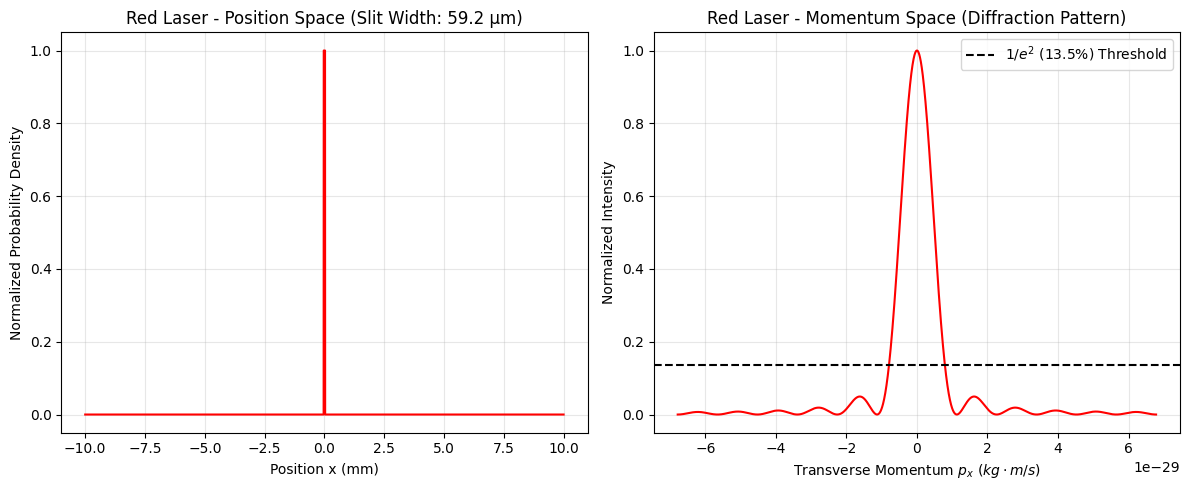

In [23]:
    #5 Plotting
    plt.figure(figsize=(12, 5))

    # Position Domain
    plt.subplot(1, 2, 1)
    # Re-normalize for plotting presentation
    plt.plot(x * 1000, np.abs(slit_wavefunction)**2 / np.max(np.abs(slit_wavefunction)**2), color=params["color"])
    plt.title(f"{name} - Position Space (Slit Width: {current_dx*1e6:.1f} µm)")
    plt.xlabel("Position x (mm)")
    plt.ylabel("Normalized Probability Density")
    plt.grid(True, alpha=0.3)

    # Momentum Domain
    plt.subplot(1, 2, 2)
    plt.plot(px, intensity_profile, color=params["color"])
    
    # 13.5% threshold line
    plt.axhline(y=0.135, color='black', linestyle='--', label='$1/e^2$ (13.5%) Threshold')
    plt.title(f"{name} - Momentum Space (Diffraction Pattern)")
    plt.xlabel(r"Transverse Momentum $p_x$ ($kg \cdot m/s$)")
    plt.ylabel("Normalized Intensity")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

This code uses MatplotLib to make a plot. 

It will show on the left, a single line or spike. It is define $\Delta x$, it is so thin to represent a really high level of position certainty. 

The right graph represents the diffraction pattern or $\Delta P_x$. It will look like a Bell Curve and shows a higher intensity closer to the middle. 

There will be a horizontal line at y=0.135 representing the 13.5% width cutoff. This is the same cutoff we used before however the final value has no dependence on what is written in here.

## 5) Final Code


=== Violet Laser ===
Slit Width (Δx): 5.92e-05 m
Momentum Spread (Δpx): 1.58e-29 kg*m/s
Calculated Uncertainty Product (Δx * Δpx): 9.37e-34 J*s
Heisenberg Uncertainty Limit (hbar/2):     5.27e-35 J*s
Heisenberg Uncertainty Principle satisfied ✓


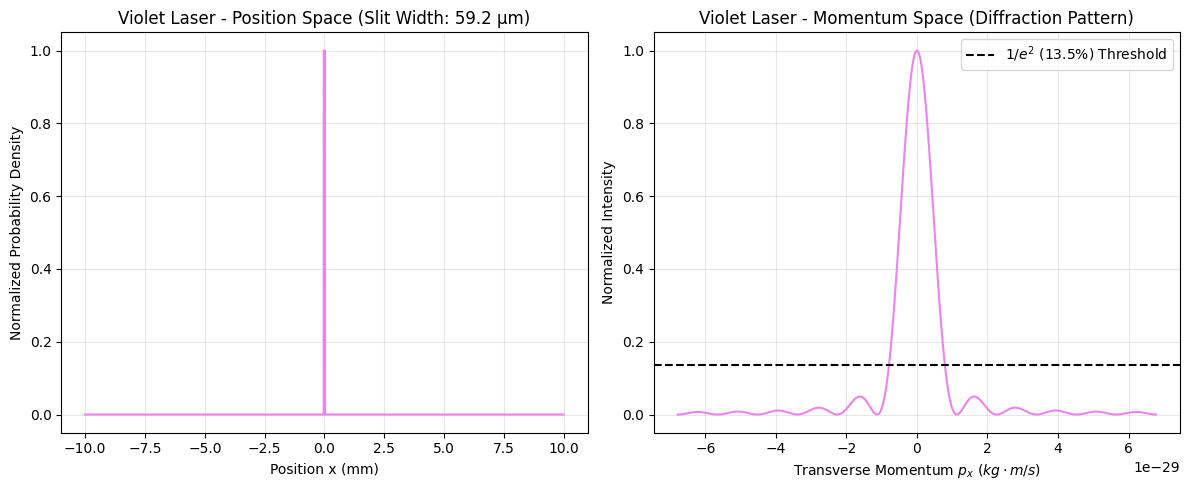


=== Red Laser ===
Slit Width (Δx): 5.92e-05 m
Momentum Spread (Δpx): 1.58e-29 kg*m/s
Calculated Uncertainty Product (Δx * Δpx): 9.37e-34 J*s
Heisenberg Uncertainty Limit (hbar/2):     5.27e-35 J*s
Heisenberg Uncertainty Principle satisfied ✓


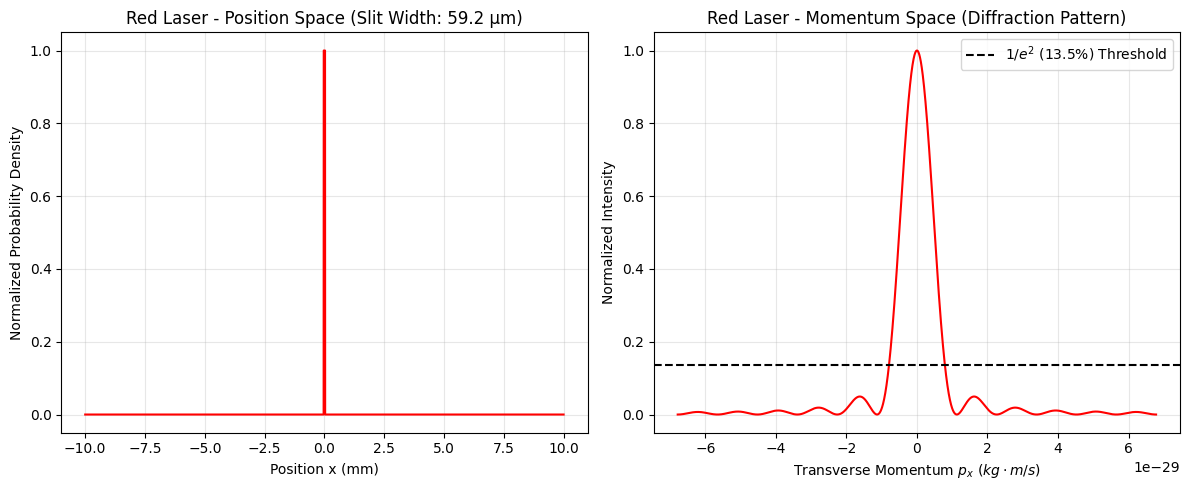

In [ ]:
#1
import numpy as np
import matplotlib.pyplot as plt

#Constants and parameters
h = 6.62607015e-34       # Planck's constant
h_bar = h / (2 * np.pi)  # Reduced Planck's constant

# Light Source Parameters
sources = {
    "Violet Laser": {"lambda": 405e-9, "color": 'violet'},
    "Red Laser": {"lambda": 650e-9, "color": 'red'}
}

# Grid Setup 
grid_size = 4096  # grid size
physical_width = 0.02
x = np.linspace(-physical_width/2, physical_width/2, grid_size)
dx = x[1] - x[0]

#2
def create_aperture(width_delta_x):
    aperture = np.zeros(grid_size)
    limit = width_delta_x / 2 # half of delta x
    aperture[(x > -limit) & (x < limit)] = 1
    
    # Normalize the position wavefunction so that its total probability integrates to 1
    aperture = aperture / np.sqrt(np.sum(np.abs(aperture)**2 * dx))
    return aperture

# Define the physical slit width (delta x)
current_dx = 5.92e-5 #From my physical lab experiment
slit_wavefunction = create_aperture(current_dx)

#3
def simulate_diffraction(aperture_wavefunction, wavelength):
    # Fast Fourier Transform to get the momentum wavefunction
    # We multiply by dx to preserve the continuous Fourier Transform scaling
    """
    Transform the position-space wavefunction into momentum space via an FFT.
    
    Converts the discrete spatial grid into a scaled representation 
    of quantum mechanical momentum states, shifting the zero-frequency 
    component to the center of the spectrum.
    
    Parameters:
    aperture_wavefunction (numpy.ndarray): Normalized position-space amplitude distribution.
    dx (float): Spatial step size between grid points (meters).
    
    Returns:
    numpy.ndarray: The centered, physically scaled momentum-space wavefunction.
    """

    momentum_wavefunction = np.fft.fft(aperture_wavefunction) * dx
    momentum_wavefunction = np.fft.fftshift(momentum_wavefunction)

    # Intensity profile in momentum space (Probability Density Function)
    intensity = np.abs(momentum_wavefunction)**2

    # Normalize intensity peak to 1 for uniform thresholding analysis
    normalized_intensity = intensity / np.max(intensity)

    frequencies = np.fft.fftfreq(grid_size, d=dx)
    frequencies_shifted = np.fft.fftshift(frequencies)
    
    # Map momentum using physical diffraction angles: sin(theta) = f * lambda
    # Total photon momentum P = h / lambda. Therefore: p_x = P * sin(theta) = h * f
    # To differentiate wavelengths, the spatial frequency grid scales with the wavelength's angular spread
    p_x = (h / wavelength) * (frequencies_shifted * wavelength)

    return p_x, normalized_intensity

#4
def get_uncertainty_product(px_axis, intensity, dx_val):
    # Finds the momentum spread at the 13.5% (1/e^2) peak intensity threshold
    cutoff = intensity > 0.135
    delta_px = np.max(px_axis[cutoff]) - np.min(px_axis[cutoff])

    product = dx_val * delta_px
    return delta_px, product

# Loop for different light sources
for name, params in sources.items():
    px, intensity_profile = simulate_diffraction(slit_wavefunction, params["lambda"])
    d_px, uncert_product = get_uncertainty_product(px, intensity_profile, current_dx)

    print(f"\n=== {name} ===")
    print(f"Slit Width (Δx): {current_dx:.2e} m")
    print(f"Momentum Spread (Δpx): {d_px:.2e} kg*m/s")
    print(f"Calculated Uncertainty Product (Δx * Δpx): {uncert_product:.2e} J*s")
    print(f"Heisenberg Uncertainty Limit (hbar/2):     {h_bar/2:.2e} J*s")

# Check for Uncertainty Principle
    if uncert_product >= (h_bar / 2):
        print("Heisenberg Uncertainty Principle satisfied ✓")
    else:
        print("Limit NOT satisfied ✗ (Check grid resolution/threshold)")
       
    #5 Plotting
    plt.figure(figsize=(12, 5))

    # Position Domain
    plt.subplot(1, 2, 1)
    # Re-normalize for plotting presentation
    plt.plot(x * 1000, np.abs(slit_wavefunction)**2 / np.max(np.abs(slit_wavefunction)**2), color=params["color"])
    plt.title(f"{name} - Position Space (Slit Width: {current_dx*1e6:.1f} µm)")
    plt.xlabel("Position x (mm)")
    plt.ylabel("Normalized Probability Density")
    plt.grid(True, alpha=0.3)

    # Momentum Domain
    plt.subplot(1, 2, 2)
    plt.plot(px, intensity_profile, color=params["color"])
    
    # 13.5% threshold line
    plt.axhline(y=0.135, color='black', linestyle='--', label='$1/e^2$ (13.5%) Threshold')
    plt.title(f"{name} - Momentum Space (Diffraction Pattern)")
    plt.xlabel(r"Transverse Momentum $p_x$ ($kg \cdot m/s$)")
    plt.ylabel("Normalized Intensity")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## References 
These are the references of this code and also my original physical experiment. I asked Gemini after using it for this project for its reference so it states what it helped with in the reference. I also included my unpublished lab paper as it is currently as a reference because I used so text from that in this paper.


[1] W. Heisenberg. "Über den anschaulichen Inhalt der quantentheoretischen Kinematik und Mechanik." In: Z. Phys. 43 (1927), pp. 172-198.   
[2] D. J. Griffiths and D. F. Schroeter. Introduction to Quantum Mechanics. 3rd ed. Cambridge University Press, Cambridge, 2018.   
[3] P. Galvez, M. Holuigue, and J. Gratton. "Verification of the uncertainty principle by using diffraction of light waves." In: Am. J. Phys. (2005).   
[4] M. Valentini et al. "Heisenberg's uncertainty principle and the quantum-to-classical transition." In: Eur. Phys. J. C 80 (2020), p. 1113.   
[5] B. E. A. Saleh and M. C. Teich. Fundamentals of Photonics. 3rd ed. Wiley, New York, 2019.   
[6] Gemini. Large Language Model, Google. Collaborative assistance in developing Python simulations for the Heisenberg Uncertainty Principle, including FFT implementation, physical constant integration, and README documentation for GitHub repository maintenance. May 2024.
[7] Moritz, R. "Testing the Uncertainty Principle in Spatially Fourier Transform Limited Systems." Unpublished lab report, April 20, 2026.

## AI Disclosure
In this project I had used ai as an assistant in completing it. I used Google Gemini. I would ask questions about how to write some specific part of code, what was wrong with code or what I could do better. When I would encounter coding issues, I would then have ai check my code to see the issues. All of the changes that ai had made were checked by me. I also used it to asking it to give me its reference.